
Script générant un attaque adverse simple : rotation. On teste :

- Tous les angles pour toutes les images pour obtenir une accuracy moyenne du réseaux sur un data set en fonction de l'angle
- Tous les angle pour chaque image pour un label donné pour obtenir les angles maximisant ou minimisant la prediction d'un réseau sur ce label


> ... TODO ... # TODO test with rotation augmentation during training


In [1]:
from retinotopy import *

Running on GPU :  NVIDIA RTX A2000 12GB #GPU= 1
------------------------------------------------------------------------------------------------
On date 2024-05-14, Running learning on host CONEC-LID-001 with device cuda, pytoch==2.3.0+cu121
------------------------------------------------------------------------------------------------
Welcome on Linux-6.5.0-1019-oem-x86_64-with-glibc2.35


# testing each network for different rotations

In [2]:
%ls -l {data_cache}/*results_test-rotations.json

-rw-r--r-- 1 perrinet.l domain users 53928813 May 11 08:05 'cached_data/2024-04-25_boxes_resnet101_do_polar=False_results_test-rotations.json'
-rw-r--r-- 1 perrinet.l domain users 53928813 May 11 07:01 'cached_data/2024-04-25_boxes_resnet101_do_polar=True_results_test-rotations.json'
-rw-r--r-- 1 perrinet.l domain users 53928813 May 11 10:06 'cached_data/2024-04-25_boxes_resnet18_do_polar=False_results_test-rotations.json'
-rw-r--r-- 1 perrinet.l domain users 53928813 May 11 09:49 'cached_data/2024-04-25_boxes_resnet18_do_polar=True_results_test-rotations.json'
-rw-r--r-- 1 perrinet.l domain users 53928813 May 11 09:33 'cached_data/2024-04-25_boxes_resnet50_do_polar=False_results_test-rotations.json'
-rw-r--r-- 1 perrinet.l domain users 53928813 May 11 08:52 'cached_data/2024-04-25_boxes_resnet50_do_polar=True_results_test-rotations.json'
-rw-r--r-- 1 perrinet.l domain users 53878213 May 11 12:30 'cached_data/2024-04-25_focus_resnet101_do_polar=False_results_test-rotations.json'
-rw-r-

In [3]:
%rm {data_cache}/*results_test-rotations.json 

In [4]:
angles = np.linspace(-180, 180, 24, endpoint=False)

In [5]:
delta_angle = angles[1] - angles[0]
angles_min = angles - delta_angle/2
angles_max = angles + delta_angle/2

# Loading and testing the networks
for data_set_type in data_set_types:
    
    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    args.do_rotation = True
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')
        
    for model_name, lw in  zip(['resnet101', 'resnet50', 'resnet18'], [4, 2, 1]): #, 
        print(f'{model_name=}')

        for do_polar in [True, False]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_test-rotations.json'
            if os.path.isfile(df_filename):
                df_angle = pd.read_json(df_filename)
            else:
                results = np.zeros((0, 3))
                model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'

                if os.path.isfile(model_filename):
                    print(f"Loading pre-trained resnet {model_filename}")
                    model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

                    for angle, angle_min, angle_max in zip(angles, angles_min, angles_max):
                        print(f'{angle=}', end='')
                        dataloaders = datasets_transforms(args, angle_min=angle_min, angle_max=angle_max, shuffle=False, verbose=False)
                        with torch.no_grad():
                            for i_image, (images, labels) in enumerate(dataloaders['val']):
                                images, labels = images.to(device), labels.to(device)

                                outputs = model(images)

                                _, preds = torch.max(outputs.data, dim=1)
                                detect = (preds == labels.data).cpu().numpy()

                                results_ = np.vstack([i_image*args.batch_size_val + np.arange(len(detect)), angle*np.ones(len(detect)), detect]).T
                                results = np.vstack((results, results_))
                        print(f', Accuracy={detect.mean():.3f}')
                    df_angle = pd.DataFrame(results, columns=['i_image', 'angle', 'match'])     
                    df_angle.to_json(df_filename)                        
                    print(25*'. ')

    print(50*'=')

data_set_type='full'
--------------------------------------------------
model_name='resnet101'
args.do_polar=True
..................................................
Loading pre-trained resnet cached_data/2024-05-14_full_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_full_resnet101_do_polar=True.pt
angle=-180.0, Accuracy=0.000
angle=-165.0, Accuracy=0.000
angle=-150.0, Accuracy=0.000
angle=-135.0, Accuracy=0.000
angle=-120.0, Accuracy=0.000
angle=-105.0, Accuracy=0.000
angle=-90.0, Accuracy=0.000
angle=-75.0, Accuracy=0.000
angle=-60.0, Accuracy=0.000
angle=-45.0, Accuracy=0.000
angle=-30.0, Accuracy=0.000
angle=-15.0, Accuracy=0.000
angle=0.0, Accuracy=0.000
angle=15.0, Accuracy=0.000
angle=30.0, Accuracy=0.000
angle=45.0, Accuracy=0.000
angle=60.0, Accuracy=0.000
angle=75.0, Accuracy=0.000
angle=90.0, Accuracy=0.000
angle=105.0, Accuracy=0.000
angle=120.0, Accuracy=0.000
angle=135.0, Accuracy=0.000
angle=150.0, Accuracy=0.000
angle=165.0, Accuracy=0.000
. . . . . . . .

/home/INT/perrinet.l/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


, Accuracy=0.404
angle=-150.0, Accuracy=0.426
angle=-135.0, Accuracy=0.426
angle=-120.0, Accuracy=0.553
angle=-105.0, Accuracy=0.489
angle=-90.0, Accuracy=0.468
angle=-75.0, Accuracy=0.489
angle=-60.0, Accuracy=0.362
angle=-45.0, Accuracy=0.362
angle=-30.0, Accuracy=0.404
angle=-15.0, Accuracy=0.596
angle=0.0, Accuracy=0.638
angle=15.0, Accuracy=0.532
angle=30.0, Accuracy=0.362
angle=45.0, Accuracy=0.319
angle=60.0, Accuracy=0.383
angle=75.0, Accuracy=0.447
angle=90.0, Accuracy=0.596
angle=105.0, Accuracy=0.489
angle=120.0, Accuracy=0.447
angle=135.0, Accuracy=0.468
angle=150.0, Accuracy=0.447
angle=165.0, Accuracy=0.468
. . . . . . . . . . . . . . . . . . . . . . . . . 
data_set_type='bbox'
--------------------------------------------------
model_name='resnet101'
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_name='resnet50'
args.do_polar=True
...........................................

# analysis: average accuracy for different rotations

In [6]:
df_angle['match'].mean()


0.4407906141035129

In [7]:
results

array([], shape=(0, 3), dtype=float64)

In [8]:
df_angle

,i_image,angle,match
0,0.0,-180.0,0.0
1,1.0,-180.0,1.0
2,2.0,-180.0,0.0
3,3.0,-180.0,1.0
4,4.0,-180.0,1.0
...,...,...,...
1199923,49992.0,165.0,1.0
1199924,49993.0,165.0,0.0
1199925,49994.0,165.0,0.0
1199926,49995.0,165.0,0.0


In [9]:
for angle in angles:   
    print(f"{angle=}, accuracy={df_angle[df_angle['angle'] == angle]['match'].mean():.3f}")

angle=-180.0, accuracy=0.401
angle=-165.0, accuracy=0.377
angle=-150.0, accuracy=0.354
angle=-135.0, accuracy=0.341
angle=-120.0, accuracy=0.345
angle=-105.0, accuracy=0.362
angle=-90.0, accuracy=0.392
angle=-75.0, accuracy=0.411
angle=-60.0, accuracy=0.445
angle=-45.0, accuracy=0.502
angle=-30.0, accuracy=0.576
angle=-15.0, accuracy=0.648
angle=0.0, accuracy=0.684
angle=15.0, accuracy=0.648
angle=30.0, accuracy=0.578
angle=45.0, accuracy=0.505
angle=60.0, accuracy=0.445
angle=75.0, accuracy=0.407
angle=90.0, accuracy=0.386
angle=105.0, accuracy=0.360
angle=120.0, accuracy=0.340
angle=135.0, accuracy=0.339
angle=150.0, accuracy=0.353
angle=165.0, accuracy=0.379


In [10]:
df_angle['match'].mean()

0.4407906141035129

In [11]:
np.hstack((angles, 180))

array([-180., -165., -150., -135., -120., -105.,  -90.,  -75.,  -60.,
        -45.,  -30.,  -15.,    0.,   15.,   30.,   45.,   60.,   75.,
         90.,  105.,  120.,  135.,  150.,  165.,  180.])

In [12]:
linestyles = ['-', '-.', ':']

In [13]:
data_set_types

['full', 'focus', 'bbox']

model_name='resnet50'
data_set_type='full'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------


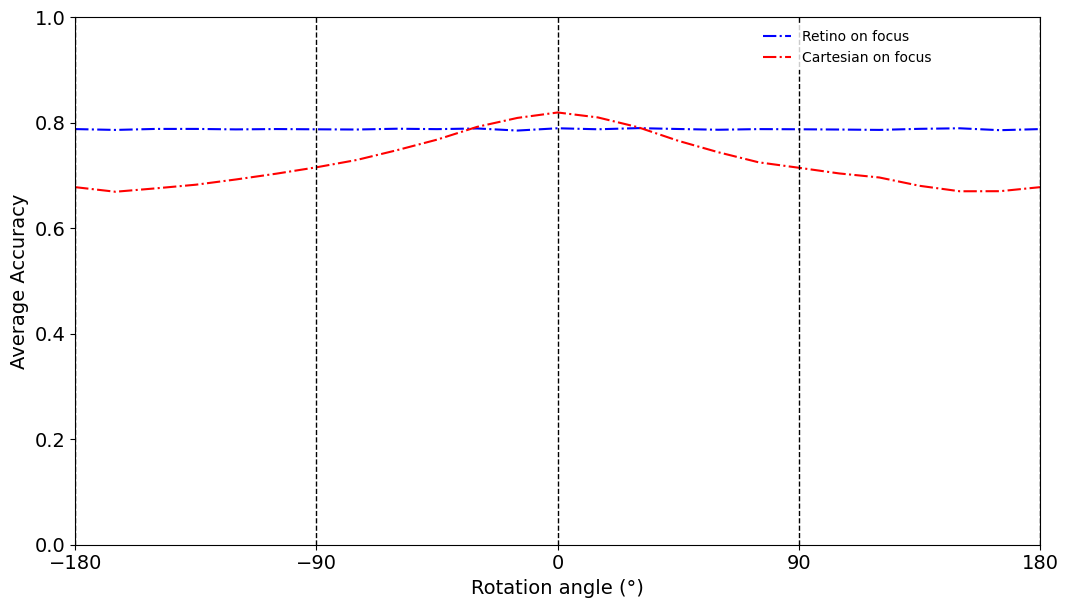

model_name='resnet18'
data_set_type='full'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------


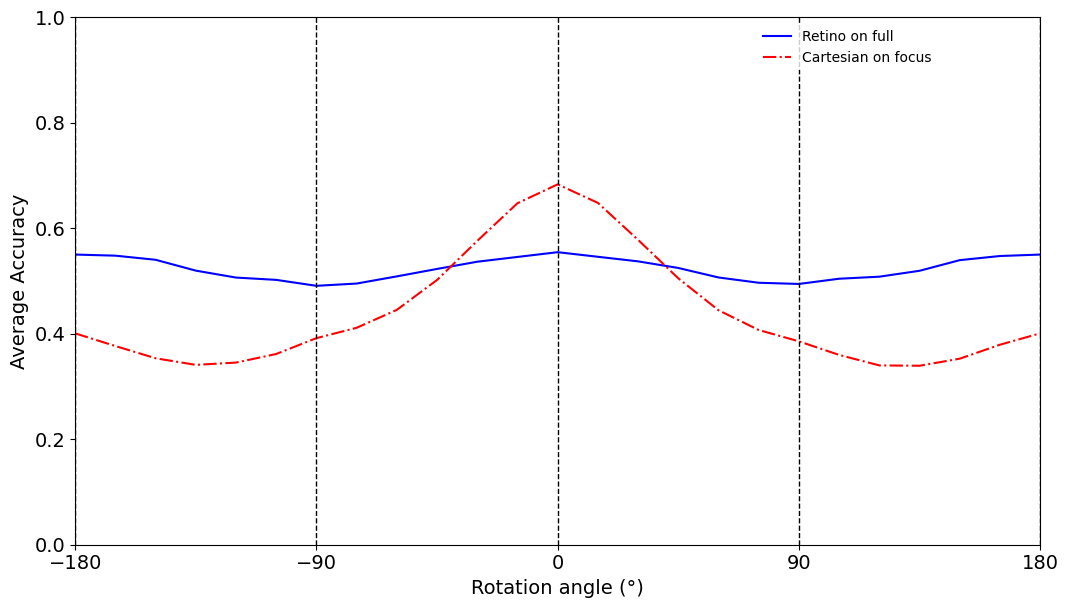

model_name='resnet101'
data_set_type='full'
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------


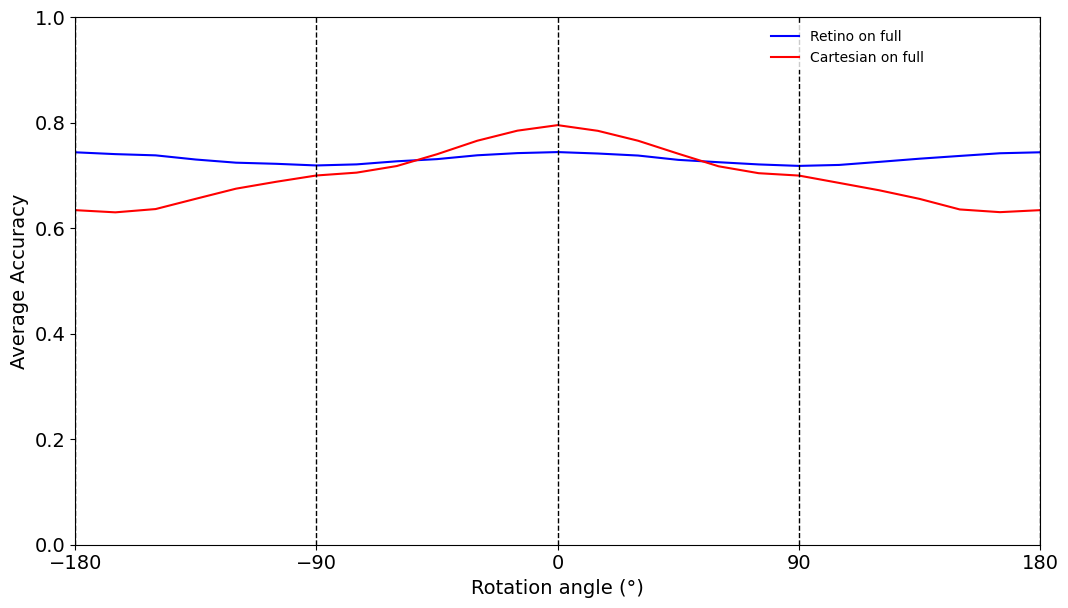

In [14]:
for model_name in  ['resnet50', 'resnet18', 'resnet101', ]:
    print(50*'=')
    print(f'{model_name=}')
    fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
    for data_set_type, ls in zip(data_set_types, linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_test-rotations.json'

            if os.path.isfile(df_filename):
                df_angle = pd.read_json(df_filename)

                results = [df_angle[df_angle['angle'] == angle]['match'].mean() for angle in np.hstack((angles, -180.))]
                label = 'Retino' if do_polar else 'Cartesian'
                label += f' on {data_set_type}'
                ax.plot(np.hstack((angles, 180)), results, color=color, ls=ls, label=label)
        
    #ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlim(-180, 180)
    ax.set_ylim(0, 1)

    for angle in [-180, -90, 0, 90, 180]:
        ax.axvline(x=angle, c='k', ls='--', lw=1)
    ax.set_xticks([-180, -90, 0, 90, 180])
    #ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
    #ax.set_yticks([.7, .75, .8])
    ax.set_ylabel('Average Accuracy', font=font)
    ax.set_xlabel('Rotation angle (°)', font=font)
    plt.legend(bbox_to_anchor=(0.8, 1), loc='upper center', fontsize=10, edgecolor='none')
    plt.tight_layout()
    # plt.xticks(font=font)
    # plt.yticks(font=font);
    plt.show()

In [15]:
for ext in exts:
    # fig.savefig(os.path.join('cached_data', f'attack_rotation_imagenet.{ext}'), **opts_savefig)
    fig.savefig(f'figs/attack_rotation_imagenet.{ext}', **opts_savefig)

# analysis: average accuracy for different rotations

In [16]:
df_angle

,i_image,angle,match
0,0,-180,1
1,1,-180,1
2,2,-180,0
3,3,-180,1
4,4,-180,1
...,...,...,...
1200019,49996,165,0
1200020,49997,165,0
1200021,49998,165,0
1200022,49999,165,0


In [17]:
df_angle[df_angle['angle']==0]['match'].mean()

0.7957840843183136

In [18]:
i_images = df_angle['i_image'].unique()
df_angle['i_image'].shape, i_images.shape

((1200024,), (50001,))

In [19]:
i_image = 0

In [20]:
all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
all_rot_matches.min(), all_rot_matches.max()

(1, 1)

In [21]:
# for i_image in i_images:
#     all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
#     if not(all_rot_matches.max() == all_rot_matches.min()):  
#         print(f'{i_image=}, {all_rot_matches}')

In [22]:
json_filename = f'{data_cache}/{datetag}_rotation_attack.json'

if os.path.isfile(model_filename):
    print(f"Load pre-computed {json_filename=}")
    df_attack = pd.read_json(json_filename, orient='index')
else:
    df_attack = pd.DataFrame([], columns=['model_name', 'data_set_type', 'do_polar', 'accuracy_before_attack', 'accuracy_after_attack']) 

    for model_name in ['resnet50', 'resnet18', 'resnet101', ]:
        print(50*'=')
        print(f'{model_name=}')
        # fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
        for data_set_type, ls in zip(data_set_types, linestyles):
            print(50*'-')
            print(f'{data_set_type=}')
            print(50*'-')

            for do_polar, color in zip([True, False], ['b', 'r']):

                df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_test-rotations.json'

                if os.path.isfile(df_filename):
                    df_angle = pd.read_json(df_filename)
                    accuracy_before_attack = df_angle[df_angle['angle']==0]['match'].mean() 

                    i_images = df_angle['i_image'].unique()
                    score = 0
                    for i_image in i_images:
                        all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
                        if not(all_rot_matches.max() == all_rot_matches.min()):  
                            score += 1 # attack succeeded !
                    accuracy_after_attack = (len(i_images)-score)/len(i_images)
                    print(f'{data_set_type=}, {do_polar=}, {accuracy_before_attack=:.3f} -  {accuracy_after_attack=:.3f}')

                    df_attack.loc[len(df_attack.index)] = [model_name, data_set_type, do_polar, accuracy_before_attack, accuracy_after_attack]

    df_attack.to_json(json_filename, orient='index', indent=2)


model_name='resnet50'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------
data_set_type='focus', do_polar=True, accuracy_before_attack=0.790 -  accuracy_after_attack=0.779
data_set_type='focus', do_polar=False, accuracy_before_attack=0.820 -  accuracy_after_attack=0.546
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
model_name='resnet18'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
data_set_type='full', do_polar=True, accuracy_before_attack=0.555 -  accuracy_after_attack=0.551
--------------------------------------------------
data_set_type='focus'
--------------------------------------------------
data_set_type='focus', do_polar=False, accura

In [23]:

# for model_name in ['resnet50', 'resnet18', 'resnet101', ]:
#     print(50*'=')
#     print(f'{model_name=}')
#     # fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))
#     for data_set_type, ls in zip(data_set_types, linestyles):
#         print(50*'-')
#         print(f'{data_set_type=}')
#         print(50*'-')

#         for do_polar, color in zip([True, False], ['b', 'r']):

#             df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_test-rotations.json'

#             if os.path.isfile(df_filename):
#                 df_angle = pd.read_json(df_filename)

#                 i_images = df_angle['i_image'].unique()
#                 score = 0
#                 for i_image in i_images:
#                     all_rot_matches = df_angle[df_angle["i_image"] == i_image]["match"]
#                     if not(all_rot_matches.max() == all_rot_matches.min()):  
#                         score += 1 # attack succeeded !
#                 accuracy_after_attack = (len(i_images)-score)/len(i_images)
#                 print(f'{data_set_type=}, {do_polar=}, {accuracy_after_attack=:.3f}')
#                 df_attack.loc[len(df_attack.index)] = [model_name, data_set_type, do_polar, accuracy_after_attack]

    #             results = [df_angle[df_angle['angle'] == angle]['match'].mean() for angle in np.hstack((angles, -180.))]
    #             label = 'Retino' if do_polar else 'Cartesian'
    #             label += f' on {data_set_type}'
    #             ax.plot(np.hstack((angles, 180)), results, color=color, ls=ls, label=label)
        
    # #ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
    # ax.tick_params(axis='x', labelsize=14)
    # ax.tick_params(axis='y', labelsize=14)
    # ax.set_xlim(-180, 180)
    # ax.set_ylim(0, 1)

    # for angle in [-180, -90, 0, 90, 180]:
    #     ax.axvline(x=angle, c='k', ls='--', lw=1)
    # ax.set_xticks([-180, -90, 0, 90, 180])
    # #ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
    # #ax.set_yticks([.7, .75, .8])
    # ax.set_ylabel('Average Accuracy', font=font)
    # ax.set_xlabel('Rotation angle (°)', font=font)
    # plt.legend(bbox_to_anchor=(0.8, 1), loc='upper center', fontsize=10, edgecolor='none')
    # plt.tight_layout()
    # # plt.xticks(font=font)
    # # plt.yticks(font=font);
    # plt.show()

In [24]:
df_attack

,model_name,data_set_type,do_polar,accuracy_before_attack,accuracy_after_attack
0,resnet50,focus,True,0.789847,0.779187
1,resnet50,focus,False,0.819789,0.545993
2,resnet18,full,True,0.554829,0.551349
3,resnet18,focus,False,0.683501,0.269876
4,resnet101,full,True,0.744685,0.703266
5,resnet101,full,False,0.795784,0.562349


In [25]:
df_attack.loc[len(df_attack.index)] = [model_name, data_set_type, do_polar, accuracy_after_attack]

ValueError: cannot set a row with mismatched columns

In [ ]:
 pd.DataFrame({'model_name': model_name, 'data_set_type':data_set_type, 'do_polar':do_polar, 'accuracy_after_attack':accuracy_after_attack})

In [ ]:
{'model_name': model_name, 'data_set_type':data_set_type, 'do_polar':do_polar, 'accuracy_after_attack':accuracy_after_attack}